# Morphological and Spectrometric Analysis of Latent Clusters

This notebook analyzes the geometric properties of the tracks discovered by the autoencoder, correlating them with underlying physical properties (e.g., alpha particle energy via Bethe-Bloch approximations, incidence angle).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# Load the dataset containing track candidates and their assigned clusters
data_path = 'outputs/candidates_labeled.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f'Successfully loaded {len(df)} tracks.')
else:
    print(f'File {data_path} not found. Generating dummy data for structural testing.')
    np.random.seed(42)
    df = pd.DataFrame({
        # 'area', 'major_axis', 'minor_axis', 'eccentricity'
        'area': np.random.normal(50, 15, 1000),
        'major': np.random.normal(10, 2, 1000),
        'minor': np.random.normal(8, 1.5, 1000),
        'ecc': np.random.uniform(0, 0.9, 1000),
        'cluster': np.random.randint(0, 6, 1000)
    })


Successfully loaded 14540 tracks.


In [3]:
# Calculate morphological statistics for each cluster
# This tabular view provides the quantitative basis for implicit spectrometry
morph_cols = ['area', 'major', 'minor', 'ecc']
available_cols = [c for c in morph_cols if c in df.columns]

if available_cols:
    cluster_stats = df.groupby('cluster')[available_cols].agg(['mean', 'std', 'median'])
    display(cluster_stats)
else:
    print('Morphological columns not found in the dataset.')


area                           major                         \
                mean         std  median        mean        std      median   
cluster                                                                       
0         120.357388   20.396036   116.0   14.069497   1.258488   13.991456   
1          32.829335    2.515051    32.0    9.163011   0.069402    9.165151   
2          64.060606    1.969464    64.0    9.168599   0.112047    9.165151   
3        2821.250000  734.861843  2541.5   69.557128   8.795448   68.431713   
4         807.482759  333.109765   698.0   37.350389   8.689097   37.632398   
5          84.048673   21.238295    82.0   16.005905   2.008592   15.182393   
6         861.440000  275.419843   766.0   45.709559  10.599848   42.517927   
7          51.717927   11.974759    56.0    8.937357   1.080332    9.165151   
8          98.344671   15.722885    96.0   14.387134   1.252679   13.938238   
9         108.952381   94.796876    71.0   18.484178   8.294862   18.404618   
10       8274.500000  103.944697  8274.5  122.380032  20.545621  122.380032   
11         74.955224   12.083444    78.0   11.916562   1.193800   11.830469   
12        104.705128   55.193428    96.5   17.805693   3.878949   18.004338   
13       4958.500000  660.517726  5034.0   91.033706  12.190319   90.443996   
14         70.628922   13.065570    72.0   10.000475   0.849688   10.327956   
15        235.116279   65.664330   216.0   20.652556   3.419210   20.073084   
16         61.499539   12.515056    60.0   11.659499   1.431002   10.891931   
17         30.829317    3.256472    32.0    8.556997   0.777247    9.165151   
18         58.803536    7.542837    64.0    8.761801   0.566725    9.165151   
19        119.642857   66.360027   124.0   25.867463   5.398758   25.953483   
20         33.201573    7.654297    30.0    9.383026   0.843478    9.383466   
21        110.768206   17.681491   108.0   14.557669   1.393550   14.178353   
22        423.631579  222.119390   308.0   61.857085   5.759215   61.854070   
23        391.439560  107.481700   377.0   26.383258   3.705142   25.873494   
24         70.190000   41.765264    56.0   14.136382   3.320457   13.808210   

             minor                             ecc                      
              mean        std     median      mean       std    median  
cluster                                                                 
0        11.207516   1.151538  10.972708  0.584777  0.115346  0.606477  
1         4.595910   0.369644   4.472136  0.863732  0.027051  0.872872  
2         9.168599   0.112047   9.165151  0.000000  0.000000  0.000000  
3        52.875198   8.247179  51.176520  0.637567  0.099240  0.645594  
4        27.562287   5.428079  25.811460  0.626642  0.164158  0.665380  
5         7.682772   1.586491   7.989050  0.865084  0.055168  0.857713  
6        25.894580   5.818774  26.557501  0.763840  0.170983  0.775332  
7         7.464950   1.043739   8.000000  0.539342  0.087861  0.491375  
8         9.135883   0.986121   9.165151  0.764328  0.061310  0.767236  
9         7.488270   4.883176   6.336093  0.868658  0.149229  0.908407  
10       89.113473  14.775439  89.113473  0.601468  0.306849  0.601468  
11        8.295467   0.585286   8.445906  0.708790  0.059311  0.701013  
12        7.851128   3.554040   7.652624  0.856991  0.131118  0.898724  
13       71.554557   3.354526  71.941042  0.579725  0.163444  0.607055  
14        9.113340   0.888244   9.165151  0.400505  0.089878  0.420624  
15       14.968969   2.360105  14.803786  0.650275  0.142901  0.664799  
16        7.651246   0.928727   7.673588  0.731954  0.100404  0.739734  
17        4.761890   0.304775   4.948717  0.821122  0.054030  0.872872  
18        8.678257   0.632179   9.165151  0.075203  0.118414  0.000000  
19        6.769264   3.247316   7.547699  0.958702  0.032369  0.962286  
20        4.877611   0.689966   4.873911  0.848857  0.047998  0.854522  
21       10.533292   0.920988  10.433316  0.675705 

/var/folders/tf/18pztg5s60xb9b8nz75clkzc0000gn/T/ipykernel_5699/2421662751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y=feature, data=df, ax=axes[i], palette='viridis', inner='quartile')
/var/folders/tf/18pztg5s60xb9b8nz75clkzc0000gn/T/ipykernel_5699/2421662751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y=feature, data=df, ax=axes[i], palette='viridis', inner='quartile')
/var/folders/tf/18pztg5s60xb9b8nz75clkzc0000gn/T/ipykernel_5699/2421662751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.viol

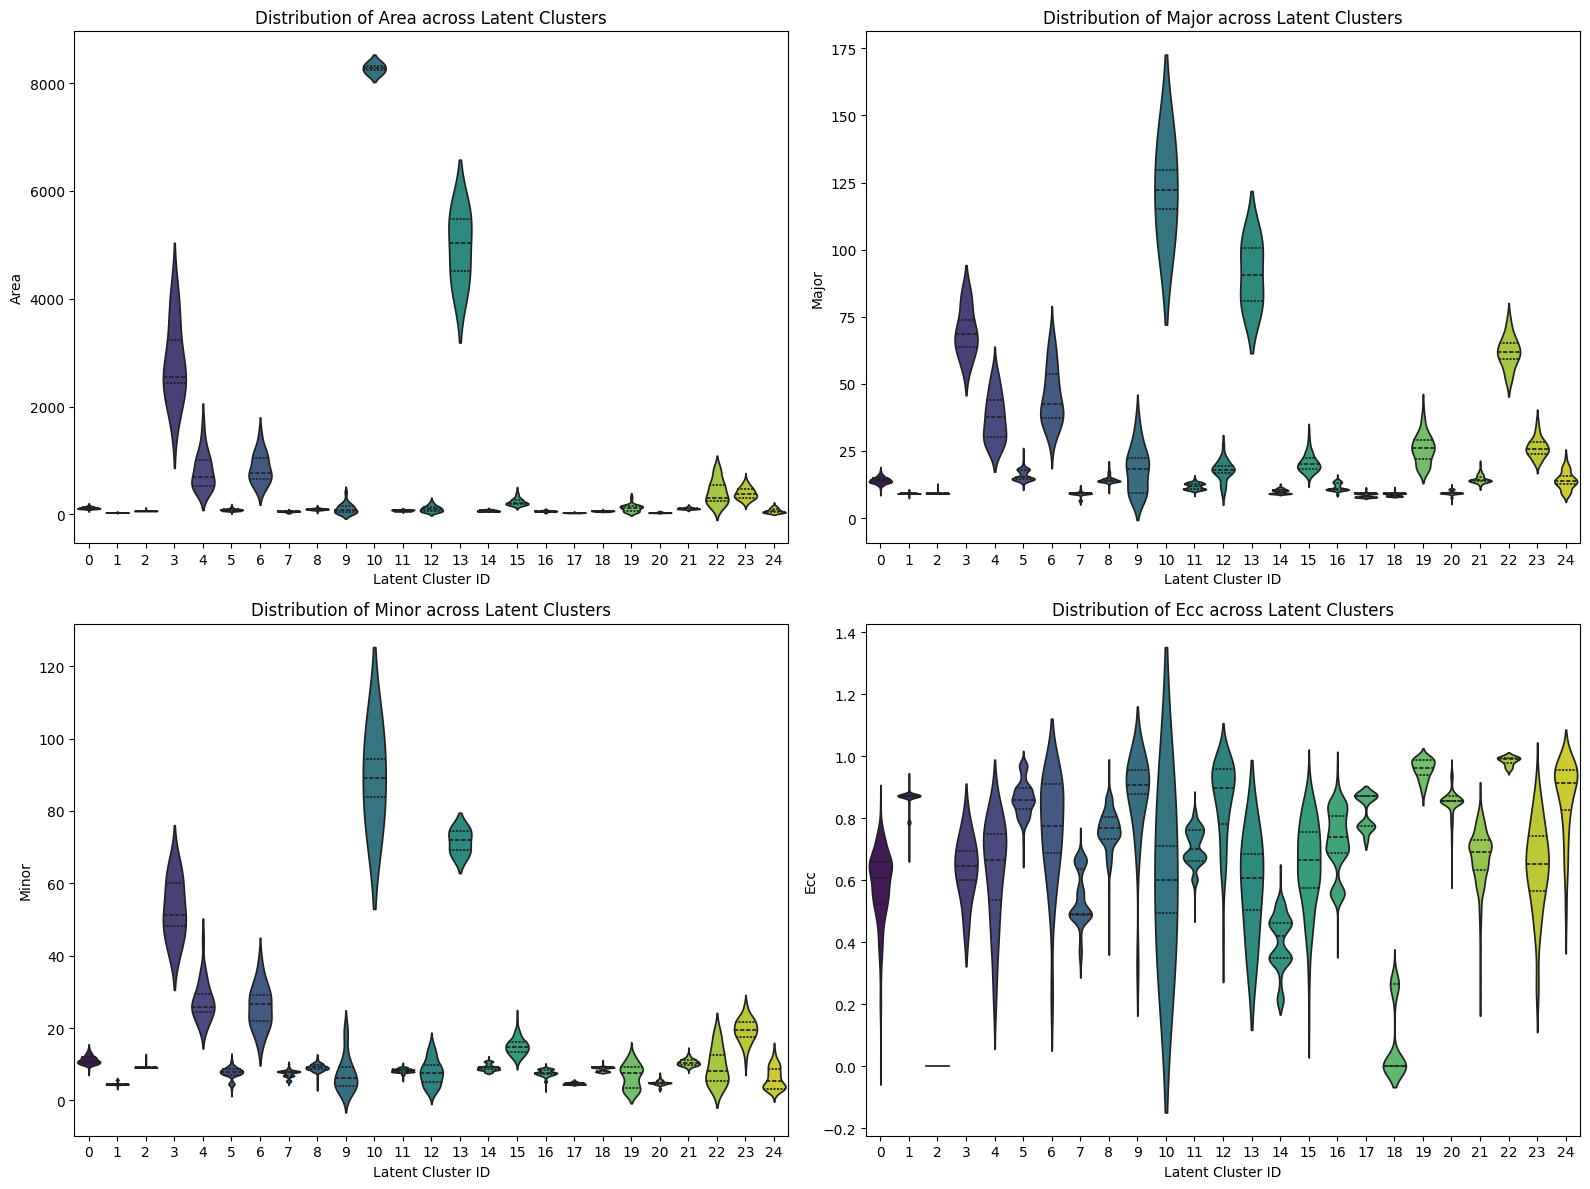

In [4]:
# Visualize the distributions to identify physical separation between clusters
if available_cols:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, feature in enumerate(available_cols):
        sns.violinplot(x='cluster', y=feature, data=df, ax=axes[i], palette='viridis', inner='quartile')
        axes[i].set_title(f'Distribution of {feature.capitalize()} across Latent Clusters')
        axes[i].set_xlabel('Latent Cluster ID')
        axes[i].set_ylabel(feature.capitalize())

    plt.tight_layout()
    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/morphology_spectrometry_violin.png', dpi=300)
    plt.show()


### Caption
### Statistical distribution of morphological track parameters across unsupervised latent clusters.
Violin plots illustrating the variance and probability density of four primary geometric features—Area, Major Axis, Minor Axis, and Eccentricity—extracted from the CR-39 alpha-particle tracks and grouped by their assigned latent cluster IDs. The model's clusters were generated via unsupervised learning (convolutional autoencoder). The white dots represent the medians, while the thick inner bars indicate the interquartile ranges. The distinct stratification of morphological distributions across different clusters demonstrates the network's ability to autonomously separate tracks based on their underlying physical properties. This geometric partitioning serves as the basis for implicit spectrometry, allowing different cluster classes to be correlated with specific alpha-particle incident energies and angles.

